# Market Basket Analysis con Apriori

Esta actividad convierte cada vivienda en una transacción de atributos categóricos para encontrar asociaciones entre precio, área, habitaciones y baños.

**Pregunta central:** ¿las viviendas con precio alto tienden también a tener un área grande?\n

Importante: el dataset no registra compras. Por tanto, las reglas representan co-ocurrencias entre características de viviendas, no decisiones de compra ni causalidad.

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
DATA_PATH = Path("data/houses.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../data/houses.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("No se encontró data/houses.csv desde la raíz o market_basket.")
df = pd.read_csv(DATA_PATH)
print(f"Viviendas analizadas: {len(df):,}")
display(df.head())

Viviendas analizadas: 940


,codigo_postal,tipo,localidad,precio(mxn_peso),habitaciones,baños,area(m2)
0,21395,Fraccionamiento,Villa Toledo,4350000,3,3,172
1,21399,Fraccionamiento,Nuevo Mexicali,2910000,3,2,115
2,21395,Fraccionamiento,Bugambilias,380000,2,1,120
3,21384,Fraccionamiento,Valle de Puebla 2da. Sección,1250000,2,1,61
4,21323,Fraccionamiento,Residencial Barcelona II,850000,3,2,170


## 1. Convertir variables continuas en ítems

Apriori trabaja con presencia/ausencia de ítems. Por ello, precio y área se convierten en terciles: bajo, medio y alto. Los puntos de corte se calculan con los datos completos, incluidos los valores atípicos.

In [16]:
price_q1, price_q2 = df["precio(mxn_peso)"].quantile([1/3, 2/3])
area_q1, area_q2 = df["area(m2)"].quantile([1/3, 2/3])
def price_category(value):
    if value <= price_q1:
        return "precio_bajo"
    if value <= price_q2:
        return "precio_medio"
    return "precio_alto"
def area_category(value):
    if value <= area_q1:
        return "area_pequena"
    if value <= area_q2:
        return "area_mediana"
    return "area_grande"
transactions = pd.DataFrame({
    "precio": df["precio(mxn_peso)"].map(price_category),
    "area": df["area(m2)"].map(area_category),
    "habitaciones": np.select(
        [df["habitaciones"] <= 2, df["habitaciones"] == 3],
        ["habitaciones_1_2", "habitaciones_3"],
        default="habitaciones_4_o_mas",
    ),
    "banos": np.select(
        [df["baños"] == 1, df["baños"] == 2],
        ["banos_1", "banos_2"],
        default="banos_3_o_mas",
    ),
})
print(f"Cortes de precio: ${price_q1:,.0f} y ${price_q2:,.0f}")
print(f"Cortes de área: {area_q1:.0f} m² y {area_q2:.0f} m²")
display(transactions.apply(pd.Series.value_counts).fillna(0).astype(int))

Cortes de precio: $2,500,000 y $4,450,000
Cortes de área: 111 m² y 172 m²


,precio,area,habitaciones,banos
area_grande,0,313,0,0
area_mediana,0,312,0,0
area_pequena,0,315,0,0
banos_1,0,0,0,267
banos_2,0,0,0,488
banos_3_o_mas,0,0,0,185
habitaciones_1_2,0,0,230,0
habitaciones_3,0,0,590,0
habitaciones_4_o_mas,0,0,120,0
precio_alto,310,0,0,0


## 2. Matriz transaccional

Cada fila representa una vivienda y cada columna indica si el ítem está presente (`True`) o no (`False`). Una transacción contiene un ítem de cada grupo: precio, área, habitaciones y baños.

In [17]:
items = sorted(set(transactions.to_numpy().ravel()))
basket = pd.DataFrame(False, index=transactions.index, columns=items)
for column in transactions.columns:
    basket.loc[transactions.index, transactions[column].unique()] = False
    for item in transactions[column].unique():
        basket.loc[transactions[column] == item, item] = True
print(f"Transacciones: {basket.shape[0]:,}")
print(f"Ítems: {basket.shape[1]}")
display(basket.head())

Transacciones: 940
Ítems: 12


,area_grande,area_mediana,area_pequena,banos_1,banos_2,banos_3_o_mas,habitaciones_1_2,habitaciones_3,habitaciones_4_o_mas,precio_alto,precio_bajo,precio_medio
0,False,True,False,False,False,True,False,True,False,False,False,True
1,False,True,False,False,True,False,False,True,False,False,False,True
2,False,True,False,True,False,False,True,False,False,False,True,False
3,False,False,True,True,False,False,True,False,False,False,True,False
4,False,True,False,False,True,False,False,True,False,False,True,False


## 3. Algoritmo Apriori

Se utiliza `min_support = 0.05`: un conjunto de ítems debe aparecer al menos en el 5% de las viviendas para considerarse frecuente. Después se generan las reglas y se conservan las que tienen `confidence >= 0.50` y `lift > 1`.

In [18]:
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.50
frequent_itemsets = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE,
)
rules = rules[rules["lift"] > 1].copy()
rules = rules.sort_values(["lift", "confidence", "support"], ascending=False)
print(f"Conjuntos frecuentes encontrados: {len(frequent_itemsets)}")
print(f"Reglas positivas encontradas: {len(rules)}")
display(frequent_itemsets.sort_values(["length", "support"], ascending=[True, False]).head(15))

Conjuntos frecuentes encontrados: 82
Reglas positivas encontradas: 137


,support,itemsets,length
7,0.627660,frozenset({habitaciones_3}),1
4,0.519149,frozenset({banos_2}),1
10,0.338298,frozenset({precio_bajo}),1
2,0.335106,frozenset({area_pequena}),1
0,0.332979,frozenset({area_grande}),1
1,0.331915,frozenset({area_mediana}),1
11,0.331915,frozenset({precio_medio}),1
9,0.329787,frozenset({precio_alto}),1
3,0.284043,frozenset({banos_1}),1
6,0.244681,frozenset({habitaciones_1_2}),1


## 4. Reglas principales

La tabla muestra los ítems del antecedente y consecuente, además de soporte, confianza y lift. Una regla como `{area_grande} → {precio_alto}` significa que, dentro de esta muestra, se observa qué proporción de las viviendas grandes también pertenece al grupo de precio alto.

In [19]:
def format_rule(value):
    return ", ".join(sorted(value))
rules_display = rules.assign(
    antecedente=rules["antecedents"].map(format_rule),
    consecuente=rules["consequents"].map(format_rule),
)[["antecedente", "consecuente", "support", "confidence", "lift"]]
display(rules_display.head(20).style.format({
    "support": "{:.3f}", "confidence": "{:.3f}", "lift": "{:.3f}"
}))

,antecedente,consecuente,support,confidence,lift
117,"habitaciones_4_o_mas, precio_alto","area_grande, banos_3_o_mas",0.061,0.740,5.117
38,"area_grande, banos_3_o_mas",habitaciones_4_o_mas,0.079,0.544,4.262
41,habitaciones_4_o_mas,"area_grande, banos_3_o_mas",0.079,0.617,4.262
115,"area_grande, habitaciones_4_o_mas","banos_3_o_mas, precio_alto",0.061,0.570,4.122
114,"area_grande, banos_3_o_mas, precio_alto",habitaciones_4_o_mas,0.061,0.509,3.987
112,"area_grande, habitaciones_4_o_mas, precio_alto",banos_3_o_mas,0.061,0.760,3.862
101,"habitaciones_4_o_mas, precio_alto",banos_3_o_mas,0.062,0.753,3.827
135,"area_pequena, banos_1","habitaciones_1_2, precio_bajo",0.134,0.708,3.824
130,"habitaciones_1_2, precio_bajo","area_pequena, banos_1",0.134,0.724,3.824
39,"area_grande, habitaciones_4_o_mas",banos_3_o_mas,0.079,0.740,3.760


## 5. Asociación entre precio y área

Se filtran las reglas que conectan explícitamente una categoría de precio con una categoría de área. Esta es la parte que responde a la hipótesis inicial del análisis.

In [20]:
price_area_rules = rules[
    rules["antecedents"].apply(lambda x: any(item.startswith("precio_") for item in x)) &
    rules["consequents"].apply(lambda x: any(item.startswith("area_") for item in x)) |
    rules["antecedents"].apply(lambda x: any(item.startswith("area_") for item in x)) &
    rules["consequents"].apply(lambda x: any(item.startswith("precio_") for item in x))
].copy()
price_area_display = price_area_rules.assign(
    antecedente=price_area_rules["antecedents"].map(format_rule),
    consecuente=price_area_rules["consequents"].map(format_rule),
)[["antecedente", "consecuente", "support", "confidence", "lift"]]
if price_area_display.empty:
    print("No se encontraron reglas precio-área con los umbrales actuales.")
else:
    display(price_area_display.style.format({
        "support": "{:.3f}", "confidence": "{:.3f}", "lift": "{:.3f}"
    }))

,antecedente,consecuente,support,confidence,lift
117,"habitaciones_4_o_mas, precio_alto","area_grande, banos_3_o_mas",0.061,0.740,5.117
115,"area_grande, habitaciones_4_o_mas","banos_3_o_mas, precio_alto",0.061,0.570,4.122
135,"area_pequena, banos_1","habitaciones_1_2, precio_bajo",0.134,0.708,3.824
130,"habitaciones_1_2, precio_bajo","area_pequena, banos_1",0.134,0.724,3.824
134,"area_pequena, habitaciones_1_2","banos_1, precio_bajo",0.134,0.759,3.464
131,"banos_1, precio_bajo","area_pequena, habitaciones_1_2",0.134,0.612,3.464
113,"banos_3_o_mas, habitaciones_4_o_mas, precio_alto",area_grande,0.061,0.983,2.951
49,"habitaciones_4_o_mas, precio_alto",area_grande,0.080,0.974,2.925
129,"area_pequena, banos_1, habitaciones_1_2",precio_bajo,0.134,0.926,2.739
109,"area_grande, banos_3_o_mas, habitaciones_3",precio_alto,0.056,0.883,2.678


### Visualización final: precio y tamaño de vivienda

El siguiente mapa de calor muestra porcentajes dentro de cada categoría de precio. Cada fila suma 100%, por lo que permite leer directamente qué proporción de viviendas de precio bajo, medio o alto es pequeña, mediana o grande.


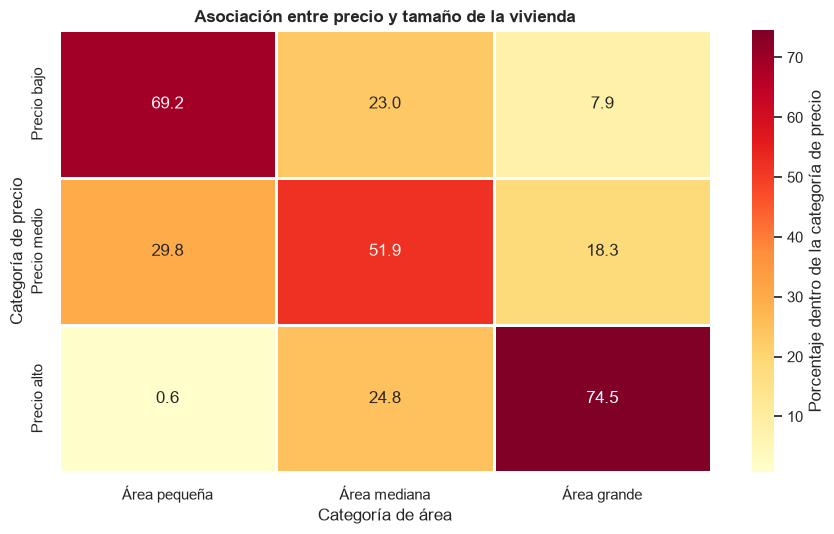

Cada fila suma 100%. En la celda Precio alto / Área grande se observa directamente la confianza de la regla precio_alto → area_grande.


,Área pequeña,Área mediana,Área grande
Precio bajo,69.2%,23.0%,7.9%
Precio medio,29.8%,51.9%,18.3%
Precio alto,0.6%,24.8%,74.5%


In [21]:
# Mapa de calor de la distribución del área dentro de cada categoría de precio.
# Se usan todas las viviendas: cada fila representa el 100% de su categoría de precio.
price_area_table = pd.crosstab(
    transactions["precio"],
    transactions["area"],
    normalize="index",
).reindex(
    index=["precio_bajo", "precio_medio", "precio_alto"],
    columns=["area_pequena", "area_mediana", "area_grande"],
).fillna(0)

price_area_table.index = ["Precio bajo", "Precio medio", "Precio alto"]
price_area_table.columns = ["Área pequeña", "Área mediana", "Área grande"]

plt.figure(figsize=(9, 5.5))
sns.heatmap(
    price_area_table * 100,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Porcentaje dentro de la categoría de precio"},
)
plt.title("Asociación entre precio y tamaño de la vivienda", fontweight="bold")
plt.xlabel("Categoría de área")
plt.ylabel("Categoría de precio")
plt.tight_layout()
plt.show()

print("Cada fila suma 100%. En la celda Precio alto / Área grande se observa directamente la confianza de la regla precio_alto → area_grande.")
display(price_area_table.mul(100).round(1).style.format("{:.1f}%"))

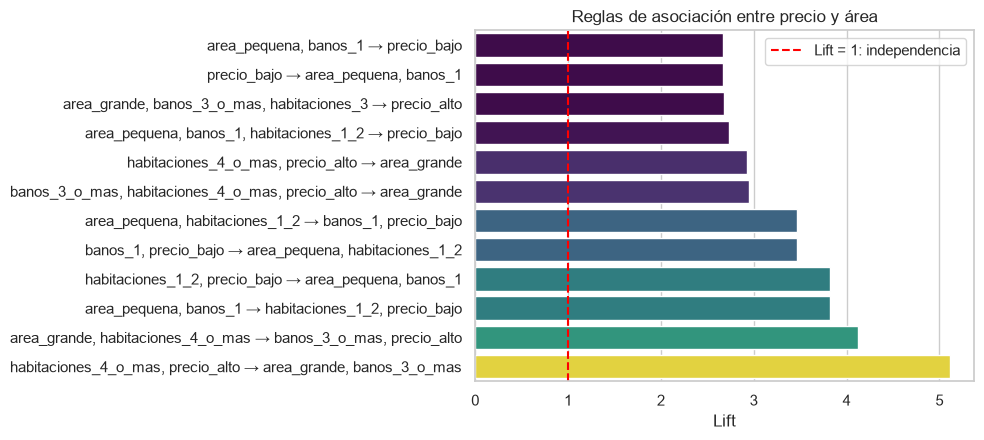

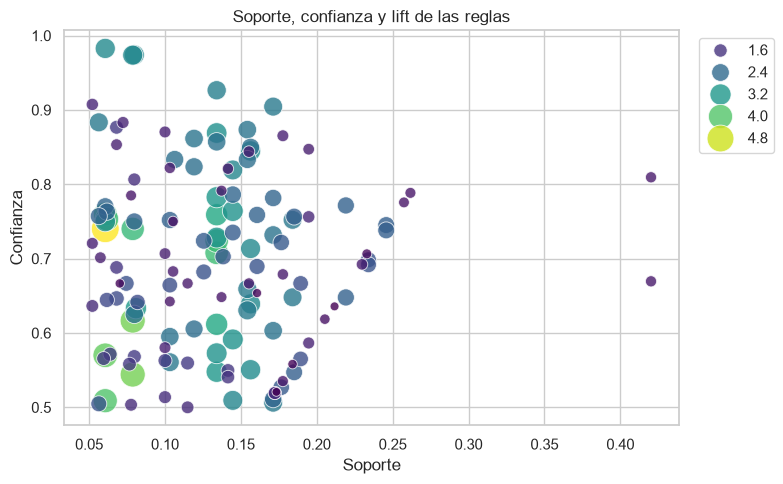

In [22]:
if not price_area_rules.empty:
    plot_rules = price_area_rules.assign(
        regla=price_area_rules["antecedents"].map(format_rule) + " → " + price_area_rules["consequents"].map(format_rule)
    ).sort_values("lift", ascending=True).tail(12)
    plt.figure(figsize=(10, max(4, len(plot_rules) * 0.38)))
    sns.barplot(data=plot_rules, x="lift", y="regla", hue="lift", palette="viridis", legend=False)
    plt.axvline(1, color="red", linestyle="--", label="Lift = 1: independencia")
    plt.title("Reglas de asociación entre precio y área")
    plt.xlabel("Lift")
    plt.ylabel("")
    plt.legend()
    plt.tight_layout()
    plt.show()
plt.figure(figsize=(8, 5))
sns.scatterplot(data=rules, x="support", y="confidence", size="lift", hue="lift", palette="viridis", sizes=(40, 400), alpha=0.8)
plt.title("Soporte, confianza y lift de las reglas")
plt.xlabel("Soporte")
plt.ylabel("Confianza")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Conclusión

Las reglas con `lift > 1` muestran asociaciones positivas entre atributos. Para comunicar una regla se deben reportar siempre sus tres métricas. Por ejemplo, una confianza de 0.80 significa que el 80% de las viviendas con el antecedente también tiene el consecuente, mientras que el lift indica si esa proporción es mayor que la esperada por la frecuencia general del consecuente.

Estas asociaciones son descriptivas. No implican causalidad y no deben interpretarse como una probabilidad universal fuera de esta muestra.